# Project Overview: Wild Blueberry Yield Prediction

**Objective:** Predict the crop yield of wild blueberries using environmental, bees pollination, and weather-specific dynamics.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s3e14')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s3e14


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
import os
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [4]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e14/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e14/test.csv')

In [5]:
train_df.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [6]:
test_df.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,15289,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.399367,0.408088,31.394569
1,15290,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,33.0,55.9,1.0,0.10,0.488048,0.442866,36.846956
2,15291,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.583379,0.487057,40.037644
3,15292,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.433014,0.422847,33.116091
4,15293,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.360996,0.388860,29.558019


### 2.2. Checking Structural Metadata

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset              15289 non-null  float64
 15  fruitmass          

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10194 non-null  int64  
 1   clonesize             10194 non-null  float64
 2   honeybee              10194 non-null  float64
 3   bumbles               10194 non-null  float64
 4   andrena               10194 non-null  float64
 5   osmia                 10194 non-null  float64
 6   MaxOfUpperTRange      10194 non-null  float64
 7   MinOfUpperTRange      10194 non-null  float64
 8   AverageOfUpperTRange  10194 non-null  float64
 9   MaxOfLowerTRange      10194 non-null  float64
 10  MinOfLowerTRange      10194 non-null  float64
 11  AverageOfLowerTRange  10194 non-null  float64
 12  RainingDays           10194 non-null  float64
 13  AverageRainingDays    10194 non-null  float64
 14  fruitset              10194 non-null  float64
 15  fruitmass          

In [9]:
train_df.shape

(15289, 18)

In [10]:
test_df.shape

(10194, 17)

In [11]:
train_df.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
yield                   0
dtype: int64

In [12]:
test_df.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
dtype: int64

## 3. Exploratory Data Analysis

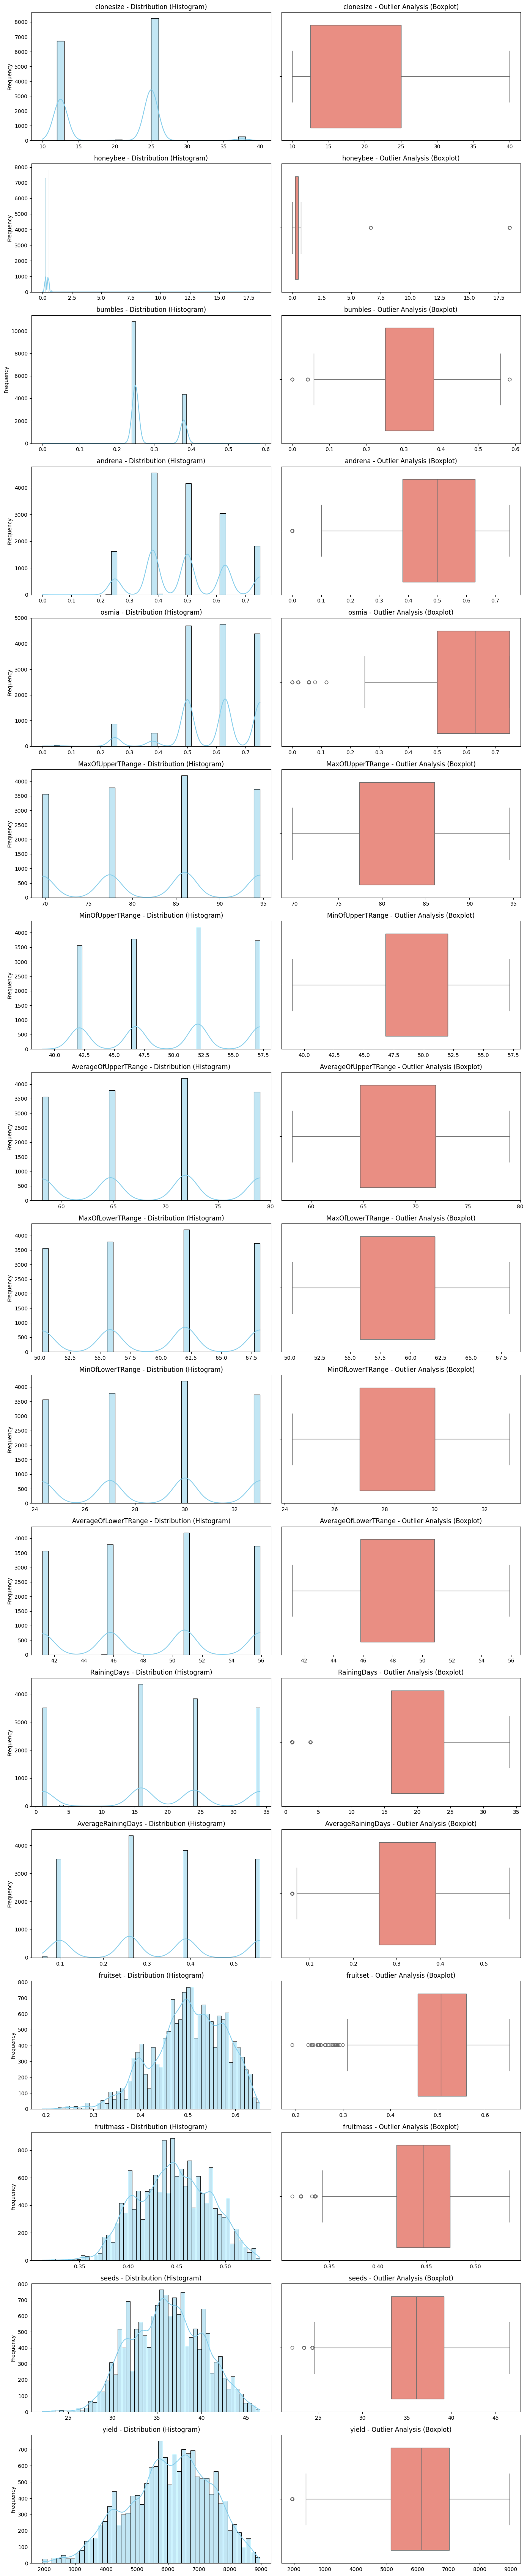

In [13]:
features_to_plot = train_df.drop(columns=['id']).columns

num_features = len(features_to_plot)
fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(14, 4 * num_features))

for i, col in enumerate(features_to_plot):
    
    # Histogram
    sns.histplot(data=train_df, x=col, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Distribution (Histogram)')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(data=train_df, x=col, ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'{col} - Outlier Analysis (Boxplot)')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

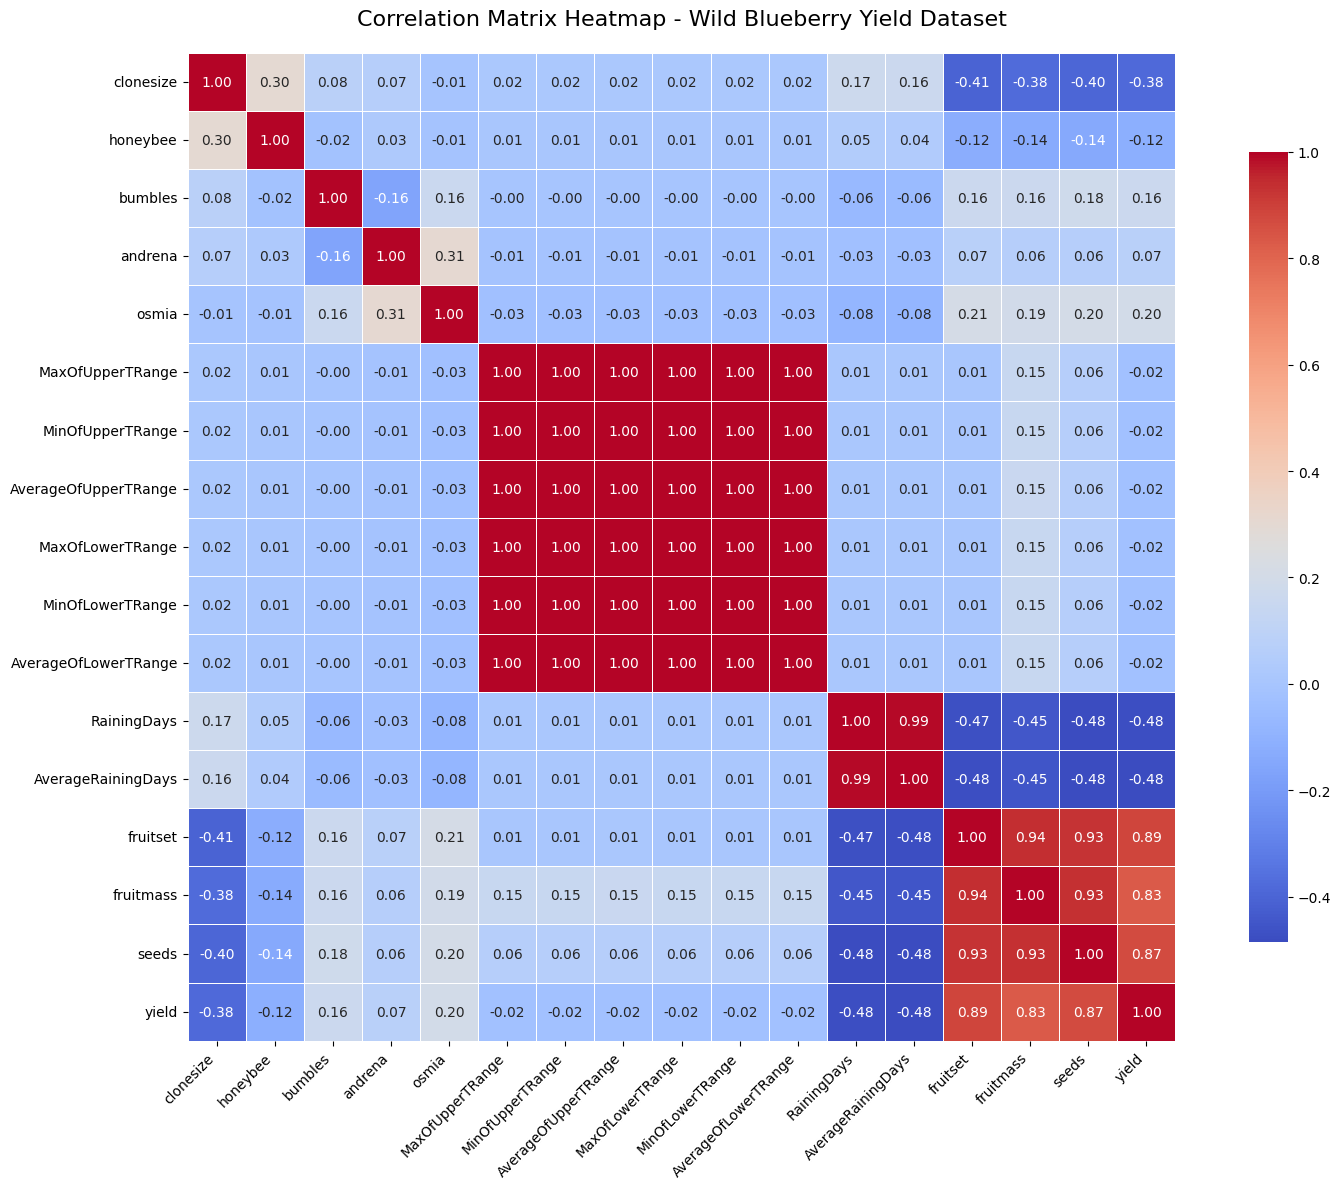

In [14]:
numeric_df = train_df.drop(columns=['id'], errors='ignore')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    square=True, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix Heatmap - Wild Blueberry Yield Dataset", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

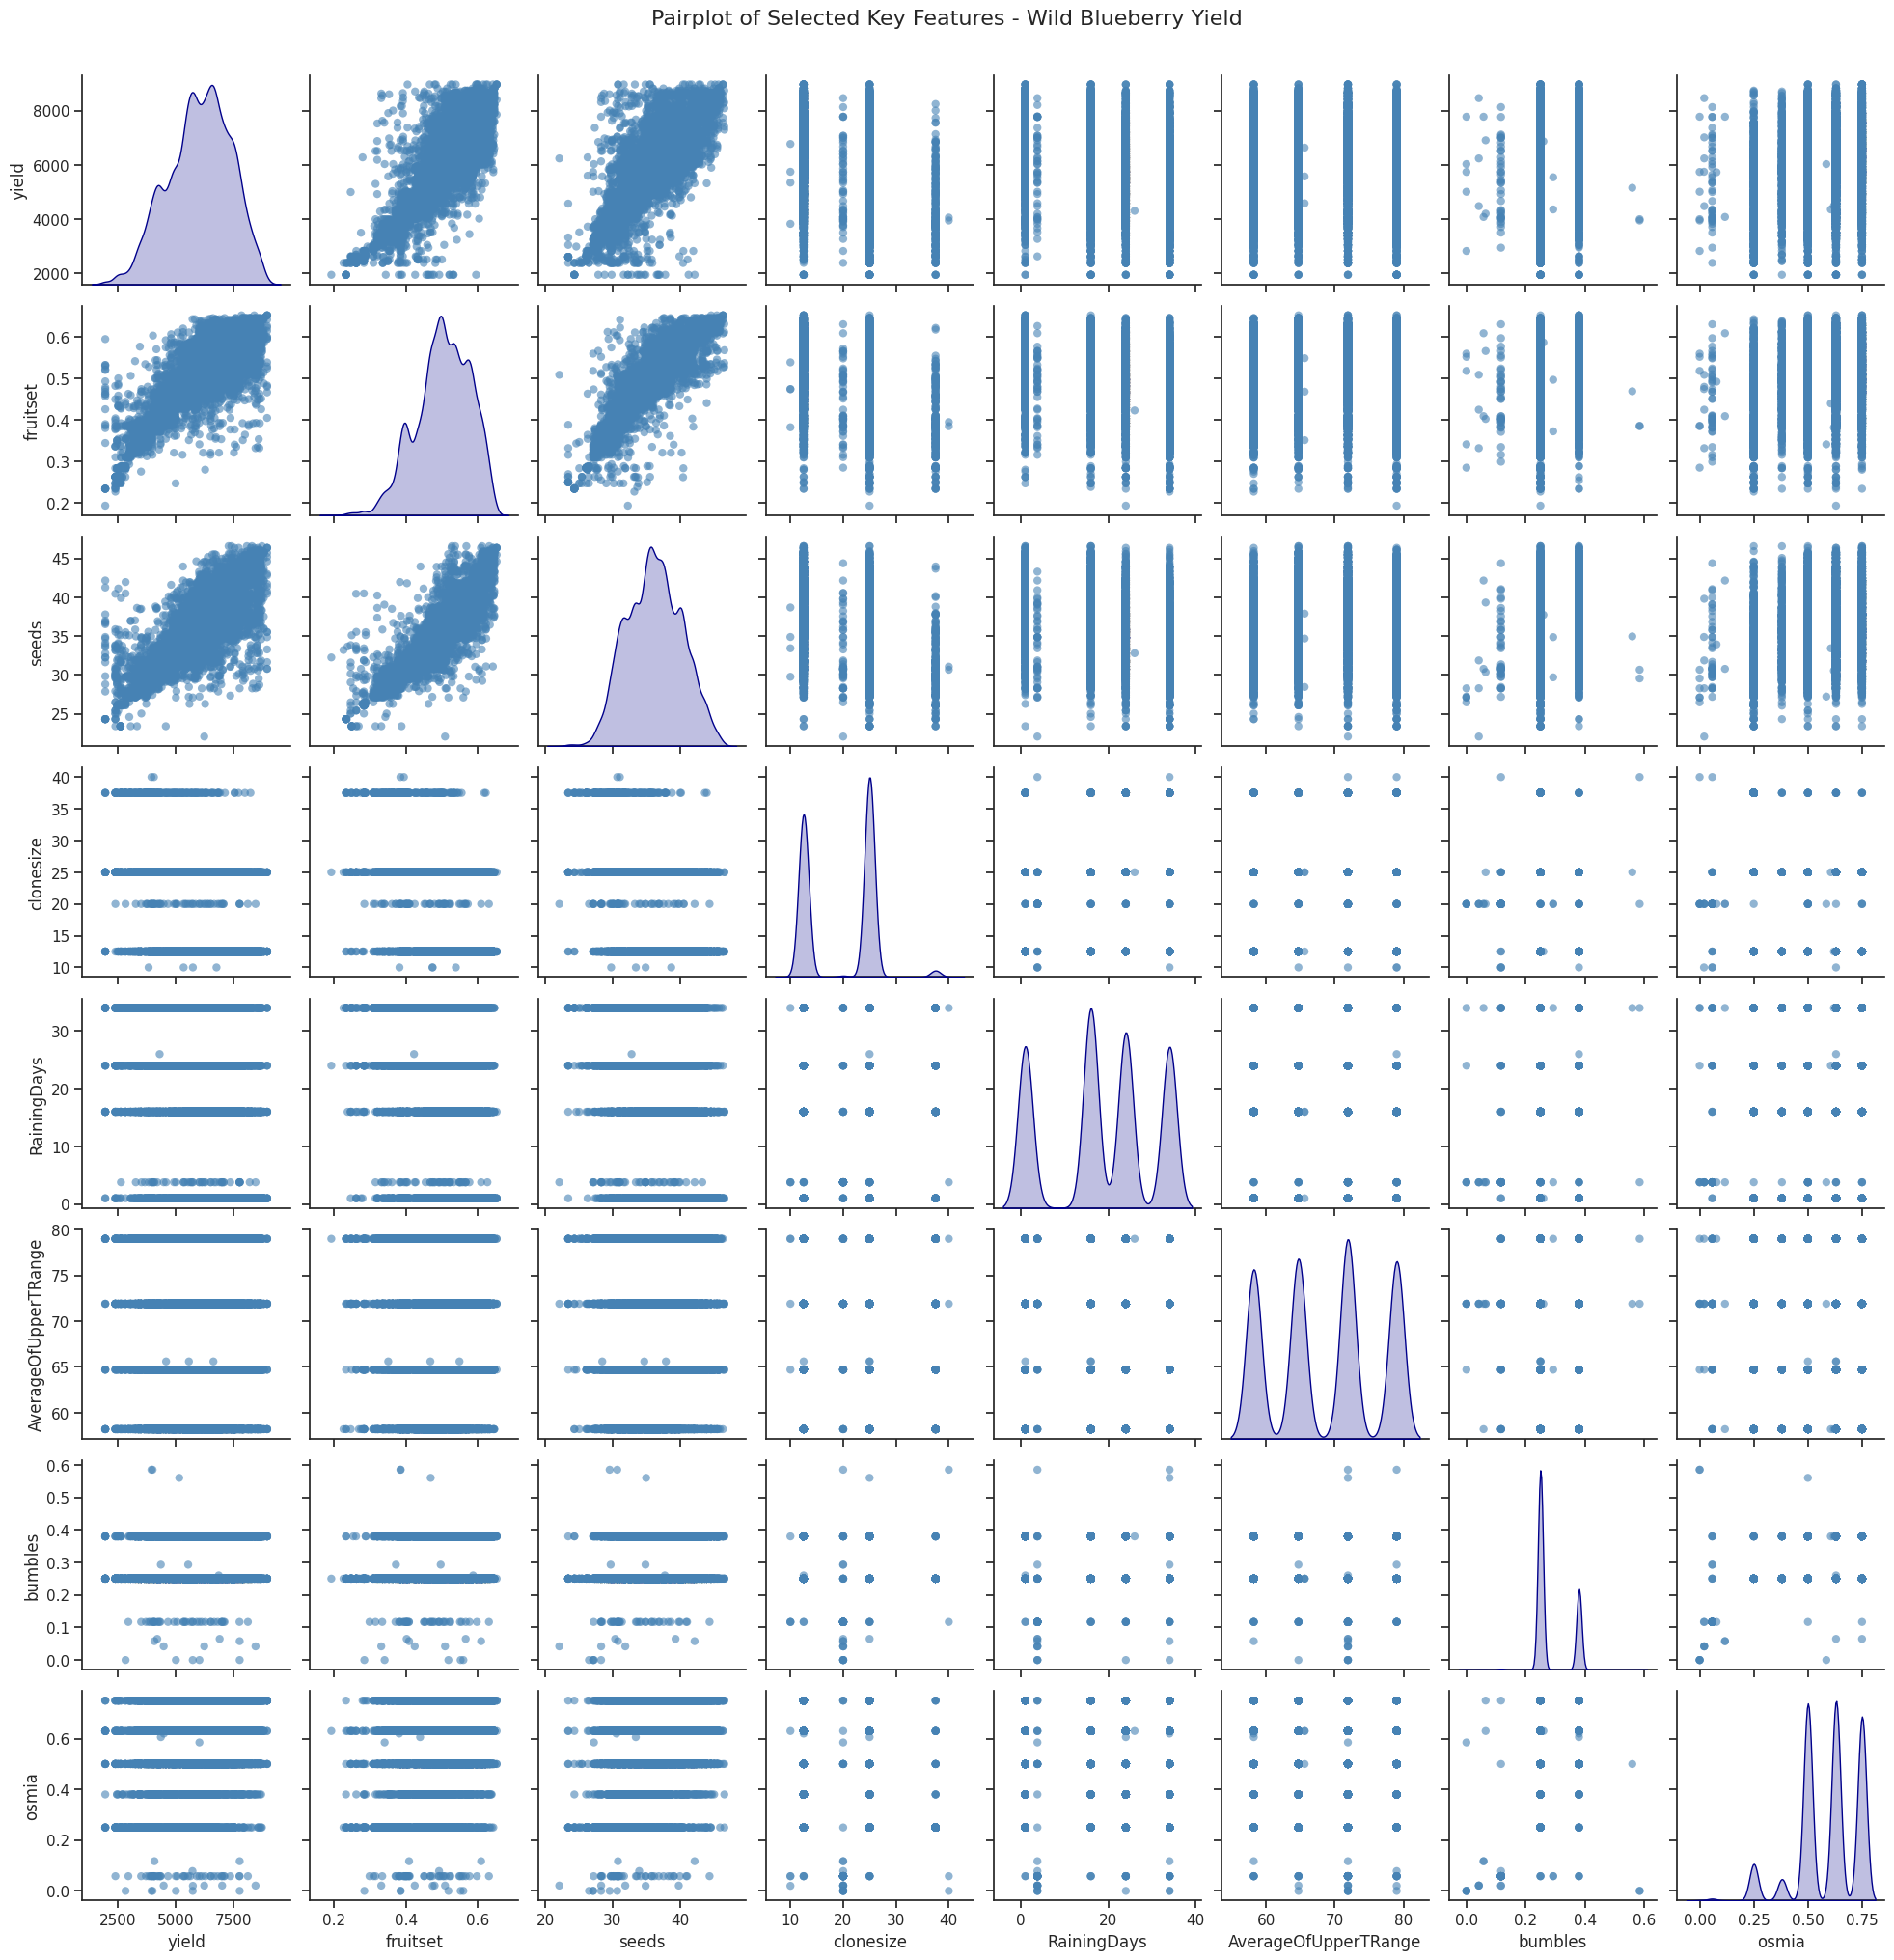

In [15]:
selected_features = [
    'yield', 
    'fruitset', 
    'seeds', 
    'clonesize', 
    'RainingDays', 
    'AverageOfUpperTRange', 
    'bumbles', 
    'osmia'
]

sns.set_theme(style="ticks")

pair_plot = sns.pairplot(
    train_df[selected_features], 
    kind='scatter', 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    diag_kws={'color': 'darkblue'}
)

pair_plot.fig.suptitle("Pairplot of Selected Key Features - Wild Blueberry Yield", y=1.02, fontsize=16)

plt.show()

## 4. Feature Engineering (FE) & Data Preprocessing

In [16]:
train_df['is_train'] = 1
test_df['is_train'] = 0

In [17]:
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [18]:
fe_combined_df = combined_df.copy()

# Pollinator Features
fe_combined_df['Total_Pollinators'] = (fe_combined_df['honeybee'] + 
                                       fe_combined_df['bumbles'] + 
                                       fe_combined_df['andrena'] + 
                                       fe_combined_df['osmia'])

In [19]:
# Count of active bee species in the area (presence)
fe_combined_df['Pollinator_Species_Count'] = (fe_combined_df[['honeybee', 'bumbles', 'andrena', 'osmia']] > 0).sum(axis=1)

In [20]:
# Fruit and Seed Quality Features
fe_combined_df['Seeds_per_Fruitmass'] = fe_combined_df['seeds'] / (fe_combined_df['fruitmass'] + 1e-6)
fe_combined_df['Fruitset_per_Seed'] = fe_combined_df['fruitset'] / (fe_combined_df['seeds'] + 1e-6)

In [21]:
# Calculate diurnal temperature range (Thermal stress/gap)
fe_combined_df['Thermal_Range'] = fe_combined_df['AverageOfUpperTRange'] - fe_combined_df['AverageOfLowerTRange']

In [22]:
columns_to_drop = [
    'MaxOfUpperTRange', 'MinOfUpperTRange', 
    'MaxOfLowerTRange', 'MinOfLowerTRange', 
    'AverageRainingDays'
]

fe_combined_df = fe_combined_df.drop(columns=columns_to_drop, errors='ignore')

In [23]:
fe_combined_df.shape

(25483, 19)

## 5. Model Training, Optimization & Deployment Strategy

In [24]:
x_train_full = fe_combined_df[fe_combined_df['is_train'] == 1].drop(columns=['is_train', 'yield'], errors='ignore')
y_train_full = fe_combined_df[fe_combined_df['is_train'] == 1]['yield']


In [25]:
x = x_train_full.drop(columns='id', errors='ignore')
y = y_train_full

In [26]:
x.shape

(15289, 16)

In [27]:
y.shape

(15289,)

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

def algo_test(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) 
    ada = AdaBoostRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor(n_jobs=-1, random_state=42)                      
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, kn, ada, dt, xgb]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Extra Tree', 'Gradient Boosting', 'KNeighbors', 'AdaBoost', 
        'Decision Tree', 'XGBRegressor'
    ]
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)
    
    for algo, name in zip(algos, algo_names):
        print(f" Now training and evaluating: {name}...")
        
        model_fit = algo.fit(x_train_scaled, y_train)
        predictions = model_fit.predict(x_test_scaled)
        
        r_squared.append(r2_score(y_test, predictions))
        rmse.append(mean_squared_error(y_test, predictions) ** 0.5)
        mae.append(mean_absolute_error(y_test, predictions))
        
    
    rtable = result.assign(R_Squared=r_squared, RMSE=rmse, MAE=mae).sort_values('R_Squared', ascending=False)
    return rtable

In [29]:
comparison_table = algo_test(x, y)

 Now training and evaluating: Linear...
 Now training and evaluating: Ridge...
 Now training and evaluating: Lasso...
 Now training and evaluating: ElasticNet...
 Now training and evaluating: SGD...
 Now training and evaluating: Extra Tree...
 Now training and evaluating: Gradient Boosting...
 Now training and evaluating: KNeighbors...
 Now training and evaluating: AdaBoost...
 Now training and evaluating: Decision Tree...
 Now training and evaluating: XGBRegressor...


In [30]:
comparison_table

,R_Squared,RMSE,MAE
Gradient Boosting,0.824338,555.700116,349.143235
Linear,0.811006,576.402591,370.990628
Ridge,0.809942,578.022297,371.574154
Lasso,0.809245,579.081162,371.918633
SGD,0.809056,579.368589,372.696759
XGBRegressor,0.803268,588.083841,379.221756
KNeighbors,0.766868,640.179999,445.812668
AdaBoost,0.672874,758.331490,554.724848
Decision Tree,0.616613,820.956176,530.018421
Extra Tree,0.598332,840.301815,541.654915


In [33]:
train_full = fe_combined_df[fe_combined_df['is_train'] == 1].copy()
test_full = fe_combined_df[fe_combined_df['is_train'] == 0].copy()

In [34]:
x_train_final = train_full.drop(columns=['id', 'is_train', 'yield'], errors='ignore')
y_train_final = train_full['yield']

In [35]:
x_test_final = test_full.drop(columns=['id', 'is_train', 'yield'], errors='ignore')

In [36]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_final)
x_test_scaled = scaler.transform(x_test_final)

In [37]:
champion_model = GradientBoostingRegressor(random_state=42)
champion_model.fit(x_train_scaled, y_train_final)

GradientBoostingRegressor(random_state=42)

In [38]:
test_predictions = champion_model.predict(x_test_scaled)

In [39]:
submission_df = pd.DataFrame({
    'id': test_full['id'].astype(int),
    'yield': test_predictions
})



In [40]:
output_dir = '/kaggle/working/'

model_export_path = os.path.join(output_dir, 'blueberry_gradient_boosting.pkl')
scaler_export_path = os.path.join(output_dir, 'blueberry_minmax_scaler.pkl')

with open(model_export_path, 'wb') as f:
    pickle.dump(champion_model, f)
    
with open(scaler_export_path, 'wb') as f:
    pickle.dump(scaler, f)